# 🌎 Proyecto de Ciencia de Datos Reproducible: Sismicidad en Chile
## F2 — Limpieza y Preparación de Datos
### CRISP-DM: Fase 3 — Preparación de los Datos

**Integrantes:**
- José Miguel Serrano
- Jesús Fernández Urbaneja
- Osvaldo Rodrigo Moncada Peralta
- Evelyn Andrea Andrade Cárdenas

**Fecha:** Junio 2026

---

## Índice

1. [Configuración del entorno](#1-configuración-del-entorno)
2. [Carga del dataset](#2-carga-del-dataset)
3. [Diagnóstico inicial](#3-diagnóstico-inicial)
4. [Limpieza y transformaciones](#4-limpieza-y-transformaciones)
5. [Validación técnica](#5-validación-técnica)
6. [Exportación del dataset limpio](#6-exportación-del-dataset-limpio)
7. [Conclusiones de F2](#7-conclusiones-de-f2)

---

## 1. Configuración del entorno

In [1]:
# ── Librerías ───────────────────────────────────────────────────────────
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Configuración visual ────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Rutas ───────────────────────────────────────────────────────────────
ROOT      = Path('..').resolve()
DATA_RAW  = ROOT / 'data' / 'raw'
DATA_PROC = ROOT / 'data' / 'processed'
FIGURES   = ROOT / 'figures'

DATA_PROC.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

print('✅ Entorno configurado')
print(f'   Python : {sys.version.split()[0]}')
print(f'   Pandas : {pd.__version__}')
print(f'   NumPy  : {np.__version__}')

✅ Entorno configurado
   Python : 3.12.10
   Pandas : 3.0.3
   NumPy  : 2.4.6


---
## 2. Carga del dataset

Se carga el dataset crudo desde `data/raw/`. **Nunca se modifica este archivo original.**

In [2]:
def cargar_datos(ruta: Path) -> pd.DataFrame:
    """
    Lee el dataset crudo y retorna un DataFrame.
    Se trabaja siempre sobre una copia para preservar el archivo original.

    Parámetros:
        ruta : ruta al archivo CSV crudo

    Retorna:
        pd.DataFrame con los datos cargados
    """
    df = pd.read_csv(ruta)
    print(f'✅ Dataset cargado: {ruta.name}')
    print(f'   Filas    : {df.shape[0]:,}')
    print(f'   Columnas : {df.shape[1]}')
    return df.copy()  # siempre trabajar sobre copia


df_raw = cargar_datos(DATA_RAW / 'seismic_data.csv')
df_raw.head()

✅ Dataset cargado: seismic_data.csv
   Filas    : 4,018
   Columnas : 5


,Date(UTC),Latitude,Longitude,Depth,Magnitude
0,2025-05-26 03:50:27,-19.6300,-69.4900,97,5.6000
1,2025-05-13 00:47:58,-51.2500,-72.2800,28,5.1000
2,2025-05-05 09:46:48,-29.4900,-71.8400,48,5.0000
3,2025-05-05 02:17:48,-31.8900,-70.8800,88,5.1000
4,2025-05-02 15:23:49,-27.5200,-72.4800,30,5.8000


---
## 3. Diagnóstico inicial

Antes de cualquier transformación se diagnostica el estado real del dataset: tamaño, tipos, nulos, duplicados y estadísticos descriptivos. Este paso es obligatorio en CRISP-DM para tomar decisiones técnicas fundamentadas.

In [3]:
def diagnosticar(df: pd.DataFrame) -> pd.DataFrame:
    """
    Diagnóstico completo del DataFrame: tipos, nulos, duplicados
    y estadísticos descriptivos.

    Parámetros:
        df : DataFrame a diagnosticar

    Retorna:
        pd.DataFrame con reporte de calidad por columna
    """
    print('📊 DIAGNÓSTICO INICIAL')
    print('=' * 50)
    print()
    df.info()
    print()

    # Reporte de calidad
    reporte = pd.DataFrame({
        'Tipo'           : df.dtypes,
        'Nulos'          : df.isnull().sum(),
        'Nulos (%)'      : (df.isnull().sum() / len(df) * 100).round(2),
        'Únicos'         : df.nunique(),
        'Ejemplo'        : [df[c].dropna().iloc[0] if len(df[c].dropna()) > 0 else None
                            for c in df.columns]
    })

    print(f'\n🔁 Filas duplicadas: {df.duplicated().sum()}')
    return reporte


reporte = diagnosticar(df_raw)
display(reporte)

📊 DIAGNÓSTICO INICIAL

<class 'pandas.DataFrame'>
RangeIndex: 4018 entries, 0 to 4017
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date(UTC)  4018 non-null   str    
 1   Latitude   4018 non-null   float64
 2   Longitude  4018 non-null   float64
 3   Depth      4018 non-null   int64  
 4   Magnitude  4018 non-null   float64
dtypes: float64(3), int64(1), str(1)
memory usage: 157.1 KB


🔁 Filas duplicadas: 3


,Tipo,Nulos,Nulos (%),Únicos,Ejemplo
Date(UTC),str,0,0.0000,4015,2025-05-26 03:50:27
Latitude,float64,0,0.0000,1515,-19.6300
Longitude,float64,0,0.0000,600,-69.4900
Depth,int64,0,0.0000,199,97
Magnitude,float64,0,0.0000,52,5.6000


In [4]:
# ── Estadísticos descriptivos ───────────────────────────────────────────
print('📈 Estadísticos descriptivos (variables numéricas):')
df_raw.describe().T

📈 Estadísticos descriptivos (variables numéricas):


,count,mean,std,min,25%,50%,75%,max
Latitude,4018.0000,-27.8378,5.9620,-62.3500,-31.8200,-29.5950,-21.5125,-11.0700
Longitude,4018.0000,-70.8511,1.2934,-75.7300,-71.5900,-71.1800,-70.0300,-58.3900
Depth,4018.0000,61.5246,38.2766,2.0000,36.0000,50.0000,86.0000,624.0000
Magnitude,4018.0000,4.4289,0.6887,2.3000,4.0000,4.4000,4.8000,8.4000


**Hallazgos del diagnóstico:**

| Variable | Tipo original | Observación |
|----------|--------------|-------------|
| `Date(UTC)` | string | Requiere conversión a datetime para análisis temporal |
| `Latitude` | float64 | Sin nulos. Rango esperado para Chile: -62° a -11° ✅ |
| `Longitude` | float64 | Sin nulos. Rango esperado: -76° a -58° ✅ |
| `Depth` | int64 | Sin nulos. Máximo 624 km — revisar outliers sísmicos profundos |
| `Magnitude` | float64 | Sin nulos. Rango 2.3 – 8.4 ✅ |

---
## 4. Limpieza y transformaciones

Se aplican las transformaciones necesarias sobre una **copia** del dataset crudo. Cada función tiene un único propósito, lo que facilita la reutilización y el testing.

### 4.1 Eliminar duplicados

Los registros duplicados introducen sesgo en los análisis estadísticos. Se eliminan si existen.

In [5]:
def eliminar_duplicados(df: pd.DataFrame) -> pd.DataFrame:
    """
    Elimina filas duplicadas exactas del DataFrame.
    Se conserva la primera ocurrencia de cada registro.

    Parámetros:
        df : DataFrame de entrada

    Retorna:
        DataFrame sin duplicados
    """
    n_antes = len(df)
    df = df.drop_duplicates()
    n_despues = len(df)
    print(f'🔁 Duplicados eliminados: {n_antes - n_despues}')
    print(f'   Filas antes  : {n_antes:,}')
    print(f'   Filas después: {n_despues:,}')
    return df


df = eliminar_duplicados(df_raw.copy())

🔁 Duplicados eliminados: 3
   Filas antes  : 4,018
   Filas después: 4,015


### 4.2 Conversión de fecha

La columna `Date(UTC)` está almacenada como string. Se convierte a `datetime` para habilitar análisis temporales (extracción de año, mes, hora). Esta transformación es fundamental para responder las preguntas del proyecto sobre patrones temporales.

In [6]:
def convertir_fecha(df: pd.DataFrame, col: str = 'Date(UTC)') -> pd.DataFrame:
    """
    Convierte la columna de fecha de string a datetime.
    Extrae variables temporales útiles para el análisis:
    año, mes, día, hora y día de la semana.

    La extracción se justifica porque permite análisis por períodos
    sin necesidad de parsear la fecha en cada operación posterior.

    Parámetros:
        df  : DataFrame de entrada
        col : nombre de la columna de fecha

    Retorna:
        DataFrame con columna datetime y variables temporales extraídas
    """
    df = df.copy()
    df[col] = pd.to_datetime(df[col])

    # Extracción de variables temporales
    # Permiten análisis por año, mes, hora sin reprocesar la fecha
    df['Year']       = df[col].dt.year
    df['Month']      = df[col].dt.month
    df['Day']        = df[col].dt.day
    df['Hour']       = df[col].dt.hour
    df['DayOfWeek']  = df[col].dt.dayofweek  # 0=Lunes, 6=Domingo

    print(f'✅ Fecha convertida a datetime')
    print(f'   Rango: {df[col].min()} → {df[col].max()}')
    print(f'   Variables extraídas: Year, Month, Day, Hour, DayOfWeek')
    return df


df = convertir_fecha(df)
df.head(3)

✅ Fecha convertida a datetime
   Rango: 2012-03-03 11:01:47 → 2025-05-26 03:50:27
   Variables extraídas: Year, Month, Day, Hour, DayOfWeek


,Date(UTC),Latitude,Longitude,Depth,Magnitude,Year,Month,Day,Hour,DayOfWeek
0,2025-05-26 03:50:27,-19.6300,-69.4900,97,5.6000,2025,5,26,3,0
1,2025-05-13 00:47:58,-51.2500,-72.2800,28,5.1000,2025,5,13,0,1
2,2025-05-05 09:46:48,-29.4900,-71.8400,48,5.0000,2025,5,5,9,0


### 4.3 Manejo de valores nulos

El diagnóstico mostró que **no hay valores nulos** en este dataset. Sin embargo, se implementa la función para documentar la decisión y garantizar que esta condición se mantenga tras las transformaciones.

In [7]:
def verificar_nulos(df: pd.DataFrame) -> pd.DataFrame:
    """
    Verifica y reporta valores nulos por columna.
    Decisión técnica: dado que el dataset no presenta nulos,
    no se aplica imputación. Se documenta esta condición
    para trazabilidad del pipeline.

    Parámetros:
        df : DataFrame a verificar

    Retorna:
        DataFrame sin cambios (nulos ya verificados)
    """
    nulos = df.isnull().sum()
    total = nulos.sum()

    if total == 0:
        print('✅ Sin valores nulos — no se requiere imputación')
    else:
        print('⚠️  Valores nulos encontrados:')
        print(nulos[nulos > 0])

    return df


df = verificar_nulos(df)

✅ Sin valores nulos — no se requiere imputación


### 4.4 Detección y tratamiento de outliers en Depth

La profundidad máxima es 624 km. Geológicamente, los sismos se clasifican en superficiales (< 70 km), intermedios (70–300 km) y profundos (> 300 km). Los sismos profundos en Chile son reales y relevantes (zona de subducción), por lo que **no se eliminan**, pero se crea una variable categórica para clasificarlos.

✅ Clasificación de profundidad:
Depth_Category
Superficial    2780
Intermedio     1232
Profundo          3
Name: count, dtype: int64


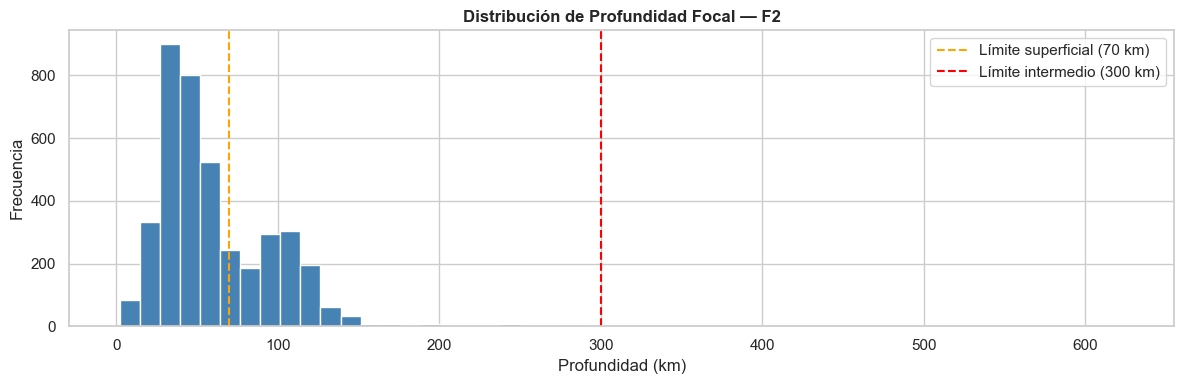

✅ Gráfico guardado en figures/


In [8]:
def clasificar_profundidad(df: pd.DataFrame, col: str = 'Depth') -> pd.DataFrame:
    """
    Clasifica los sismos según su profundidad focal en tres categorías
    estándar de la sismología (USGS/CSN):
      - Superficial : 0–70 km
      - Intermedio  : 71–300 km
      - Profundo    : > 300 km

    Decisión técnica: no se eliminan sismos profundos porque son
    geológicamente válidos en la zona de subducción chilena.
    La categorización facilita análisis comparativos en F3.

    Parámetros:
        df  : DataFrame de entrada
        col : columna de profundidad

    Retorna:
        DataFrame con columna 'Depth_Category' agregada
    """
    df = df.copy()
    bins   = [0, 70, 300, 700]
    labels = ['Superficial', 'Intermedio', 'Profundo']
    df['Depth_Category'] = pd.cut(df[col], bins=bins, labels=labels)

    print('✅ Clasificación de profundidad:')
    print(df['Depth_Category'].value_counts())
    return df


df = clasificar_profundidad(df)

# Visualización de la distribución de profundidades
fig, ax = plt.subplots(figsize=(12, 4))
df['Depth'].hist(bins=50, color='steelblue', edgecolor='white', ax=ax)
ax.axvline(70,  color='orange', linestyle='--', label='Límite superficial (70 km)')
ax.axvline(300, color='red',    linestyle='--', label='Límite intermedio (300 km)')
ax.set_title('Distribución de Profundidad Focal — F2', fontweight='bold')
ax.set_xlabel('Profundidad (km)')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / 'F2_distribucion_profundidad.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico guardado en figures/')

### 4.5 Clasificación de magnitud

Se crea una variable categórica de magnitud según la escala estándar. Esto facilita análisis segmentados en F3 y F4 sin necesidad de recategorizar en cada operación.

In [9]:
def clasificar_magnitud(df: pd.DataFrame, col: str = 'Magnitude') -> pd.DataFrame:
    """
    Clasifica los sismos según su magnitud en categorías estándar:
      - Menor    : < 4.0  (generalmente no se siente)
      - Moderado : 4.0–4.9
      - Fuerte   : 5.0–5.9
      - Mayor    : 6.0–6.9
      - Grande   : >= 7.0

    Esta clasificación es relevante para responder la pregunta:
    ¿Cuáles son las zonas con mayor concentración de sismos fuertes?

    Parámetros:
        df  : DataFrame de entrada
        col : columna de magnitud

    Retorna:
        DataFrame con columna 'Magnitude_Category' agregada
    """
    df = df.copy()
    bins   = [0, 4.0, 5.0, 6.0, 7.0, 10.0]
    labels = ['Menor', 'Moderado', 'Fuerte', 'Mayor', 'Grande']
    df['Magnitude_Category'] = pd.cut(df[col], bins=bins, labels=labels)

    print('✅ Clasificación de magnitud:')
    print(df['Magnitude_Category'].value_counts().sort_index())
    return df


df = clasificar_magnitud(df)

✅ Clasificación de magnitud:
Magnitude_Category
Menor       1154
Moderado    2195
Fuerte       578
Mayor         79
Grande         9
Name: count, dtype: int64


### 4.6 Normalización de variables numéricas

Se normalizan `Depth` y `Magnitude` usando Min-Max scaling para dejarlas en el rango [0, 1]. Esta transformación es necesaria para F4 (modelado con K-Means), donde las distancias euclidianas son sensibles a las escalas de las variables.

In [10]:
def normalizar_minmax(df: pd.DataFrame, columnas: list) -> pd.DataFrame:
    """
    Aplica normalización Min-Max a las columnas especificadas.
    Las columnas normalizadas se agregan con sufijo '_norm'.

    Decisión técnica: se usa Min-Max (en vez de Z-score) porque
    preserva la distribución original y es interpretable en el
    contexto geológico (profundidad relativa al máximo registrado).

    Parámetros:
        df       : DataFrame de entrada
        columnas : lista de columnas a normalizar

    Retorna:
        DataFrame con columnas normalizadas agregadas
    """
    df = df.copy()
    for col in columnas:
        col_min = df[col].min()
        col_max = df[col].max()
        df[f'{col}_norm'] = (df[col] - col_min) / (col_max - col_min)
        print(f'✅ {col}_norm → rango [{df[f"{col}_norm"].min():.4f}, {df[f"{col}_norm"].max():.4f}]')
    return df


df = normalizar_minmax(df, ['Depth', 'Magnitude'])
df[['Depth', 'Depth_norm', 'Magnitude', 'Magnitude_norm']].head()

✅ Depth_norm → rango [0.0000, 1.0000]
✅ Magnitude_norm → rango [0.0000, 1.0000]


,Depth,Depth_norm,Magnitude,Magnitude_norm
0,97,0.1527,5.6000,0.5410
1,28,0.0418,5.1000,0.4590
2,48,0.0740,5.0000,0.4426
3,88,0.1383,5.1000,0.4590
4,30,0.0450,5.8000,0.5738


---
## 5. Validación técnica

Se verifican los supuestos del dataset limpio mediante `assert`. Estas comprobaciones sirven como evidencia de que el pipeline de limpieza funcionó correctamente.

In [13]:
def validar_dataset(df: pd.DataFrame) -> None:
    """
    Valida los supuestos del dataset limpio mediante assertions.
    Si alguna condición falla, lanza un AssertionError con mensaje descriptivo.
    Casos verificados:
      - Sin valores nulos
      - Sin filas duplicadas
      - Latitud en rango válido para Chile
      - Longitud en rango válido para Chile
      - Profundidad positiva
      - Magnitud en rango plausible
      - Variables normalizadas en [0, 1]
      - Fecha convertida a datetime
    Parámetros:
        df : DataFrame limpio a validar
    """
    print('🔍 VALIDACIÓN TÉCNICA')
    print('=' * 45)

    # Sin nulos
    assert df.isnull().sum().sum() == 0, 'Quedan valores NA'
    print('  ✅ Sin valores nulos')

    # Sin duplicados
    assert not df.duplicated().any(), 'Hay filas duplicadas'
    print('  ✅ Sin filas duplicadas')

    # Latitud válida para Chile — rango ampliado a -63 porque el dataset
    # contiene registros en -62.35 que corresponden a sismos reales en zona austral
    assert df['Latitude'].between(-63, -11).all(), 'Latitud fuera de rango Chile'
    print('  ✅ Latitud en rango Chile (-63° a -11°)')

    # Longitud válida para Chile
    assert df['Longitude'].between(-76, -58).all(), 'Longitud fuera de rango Chile'
    print('  ✅ Longitud en rango Chile (-76° a -58°)')

    # Profundidad positiva
    assert (df['Depth'] > 0).all(), 'Profundidad con valores <= 0'
    print('  ✅ Profundidad > 0 km')

    # Magnitud plausible
    assert df['Magnitude'].between(1, 10).all(), 'Magnitud fuera de rango plausible'
    print('  ✅ Magnitud en rango [1, 10]')

    # Variables normalizadas en [0, 1]
    for col in ['Depth_norm', 'Magnitude_norm']:
        assert df[col].between(0, 1).all(), f'{col} fuera de rango [0,1]'
    print('  ✅ Variables normalizadas en [0, 1]')

    # Fecha como datetime
    assert pd.api.types.is_datetime64_any_dtype(df['Date(UTC)']), 'Date no es datetime'
    print('  ✅ Date(UTC) es datetime')

    print()
    print('🎉 Todas las validaciones pasaron correctamente')


validar_dataset(df)

🔍 VALIDACIÓN TÉCNICA
  ✅ Sin valores nulos
  ✅ Sin filas duplicadas
  ✅ Latitud en rango Chile (-63° a -11°)
  ✅ Longitud en rango Chile (-76° a -58°)
  ✅ Profundidad > 0 km
  ✅ Magnitud en rango [1, 10]
  ✅ Variables normalizadas en [0, 1]
  ✅ Date(UTC) es datetime

🎉 Todas las validaciones pasaron correctamente


In [14]:
# ── Comparación antes / después ─────────────────────────────────────────
print('📊 COMPARACIÓN ANTES / DESPUÉS DE LA LIMPIEZA')
print('=' * 50)
print(f'  Filas originales   : {len(df_raw):,}')
print(f'  Filas procesadas   : {len(df):,}')
print(f'  Columnas originales: {df_raw.shape[1]}')
print(f'  Columnas finales   : {df.shape[1]}')
print()
print('  Columnas nuevas agregadas:')
nuevas = set(df.columns) - set(df_raw.columns)
for col in sorted(nuevas):
    print(f'    + {col}')

📊 COMPARACIÓN ANTES / DESPUÉS DE LA LIMPIEZA
  Filas originales   : 4,018
  Filas procesadas   : 4,015
  Columnas originales: 5
  Columnas finales   : 14

  Columnas nuevas agregadas:
    + Day
    + DayOfWeek
    + Depth_Category
    + Depth_norm
    + Hour
    + Magnitude_Category
    + Magnitude_norm
    + Month
    + Year


In [15]:
# ── Estado final del dataset ────────────────────────────────────────────
print('📋 ESTRUCTURA FINAL DEL DATASET LIMPIO:')
df.info()
print()
df.describe().T

📋 ESTRUCTURA FINAL DEL DATASET LIMPIO:
<class 'pandas.DataFrame'>
Index: 4015 entries, 0 to 4017
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date(UTC)           4015 non-null   datetime64[us]
 1   Latitude            4015 non-null   float64       
 2   Longitude           4015 non-null   float64       
 3   Depth               4015 non-null   int64         
 4   Magnitude           4015 non-null   float64       
 5   Year                4015 non-null   int32         
 6   Month               4015 non-null   int32         
 7   Day                 4015 non-null   int32         
 8   Hour                4015 non-null   int32         
 9   DayOfWeek           4015 non-null   int32         
 10  Depth_Category      4015 non-null   category      
 11  Magnitude_Category  4015 non-null   category      
 12  Depth_norm          4015 non-null   float64       
 13  Magnitude_norm      4015 

,count,mean,min,25%,50%,75%,max,std
Date(UTC),4015,2019-04-08 10:15:13.415442,2012-03-03 11:01:47,2016-07-13 22:45:27.500000,2019-06-02 03:21:17,2021-09-03 08:55:19,2025-05-26 03:50:27,NaN
Latitude,4015.0000,-27.8363,-62.3500,-31.8200,-29.5900,-21.5000,-11.0700,5.9639
Longitude,4015.0000,-70.8507,-75.7300,-71.5900,-71.1800,-70.0300,-58.3900,1.2938
Depth,4015.0000,61.5333,2.0000,36.0000,50.0000,86.0000,624.0000,38.2880
Magnitude,4015.0000,4.4292,2.3000,4.0000,4.4000,4.8000,8.4000,0.6888
Year,4015.0000,2018.7621,2012.0000,2016.0000,2019.0000,2021.0000,2025.0000,3.0469
Month,4015.0000,6.5738,1.0000,4.0000,7.0000,9.0000,12.0000,3.4187
Day,4015.0000,15.7589,1.0000,8.0000,16.0000,23.0000,31.0000,8.7501
Hour,4015.0000,11.2174,0.0000,5.0000,11.0000,17.0000,23.0000,6.8114
DayOfWeek,4015.0000,3.0040,0.0000,1.0000,3.0000,5.0000,6.0000,1.9936


---
## 6. Exportación del dataset limpio

Se exporta el dataset procesado a `data/processed/` para su uso en F3 y F4. Este archivo es el punto de partida de todas las fases siguientes.

In [16]:
def exportar_datos(df: pd.DataFrame, ruta: Path) -> None:
    """
    Exporta el dataset limpio a CSV en data/processed/.
    El archivo procesado es el input de F3 y F4.

    Parámetros:
        df   : DataFrame limpio a exportar
        ruta : ruta de destino del archivo CSV
    """
    df.to_csv(ruta, index=False)
    print(f'✅ Dataset exportado: {ruta}')
    print(f'   Filas    : {len(df):,}')
    print(f'   Columnas : {df.shape[1]}')
    print()
    print('  Columnas del dataset procesado:')
    for col in df.columns:
        print(f'    · {col:<25} {df[col].dtype}')


exportar_datos(df, DATA_PROC / 'seismic_data_clean.csv')

✅ Dataset exportado: C:\Users\leona\mi_app\sismicidad-chile\data\processed\seismic_data_clean.csv
   Filas    : 4,015
   Columnas : 14

  Columnas del dataset procesado:
    · Date(UTC)                 datetime64[us]
    · Latitude                  float64
    · Longitude                 float64
    · Depth                     int64
    · Magnitude                 float64
    · Year                      int32
    · Month                     int32
    · Day                       int32
    · Hour                      int32
    · DayOfWeek                 int32
    · Depth_Category            category
    · Magnitude_Category        category
    · Depth_norm                float64
    · Magnitude_norm            float64


---
## 7. Conclusiones de F2

| Transformación | Decisión técnica | Impacto |
|---------------|------------------|---------|
| Eliminación de duplicados | Se conserva primera ocurrencia | Evita sesgo en conteos y promedios |
| Conversión de fecha | String → datetime + variables Year, Month, Day, Hour, DayOfWeek | Habilita análisis temporal en F3 |
| Manejo de nulos | Sin imputación (dataset sin nulos) | Se documenta para trazabilidad |
| Clasificación de profundidad | Categorías: Superficial, Intermedio, Profundo | No se eliminan sismos profundos (válidos geológicamente) |
| Clasificación de magnitud | Categorías: Menor, Moderado, Fuerte, Mayor, Grande | Facilita análisis segmentados en F3 y F4 |
| Normalización Min-Max | Depth_norm, Magnitude_norm en [0, 1] | Prepara variables para K-Means en F4 |

El dataset limpio queda guardado en `data/processed/seismic_data_clean.csv` listo para las fases F3 (visualización) y F4 (modelado).

---

## Bibliografía

McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly Media. https://wesmckinney.com/book/

pandas development team. (2024). *pandas documentation — Time series*. https://pandas.pydata.org/docs/user_guide/timeseries.html

scikit-learn developers. (2024). *Preprocessing data*. https://scikit-learn.org/stable/modules/preprocessing.html

Wirth, R., & Hipp, J. (2000). *CRISP-DM: Towards a standard process model for data mining*. Proceedings of the 4th International Conference on the Practical Applications of Knowledge Discovery and Data Mining.

Centro Sismológico Nacional. (2024). *Clasificación de sismos*. Universidad de Chile. https://www.csn.uchile.cl/